<a href="https://colab.research.google.com/github/Divanshu-Bansal/Machine-Learning-Algorithms/blob/master/K_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import make_blobs

X,y = make_blobs(n_samples=1000, n_features=2, centers=3, random_state=42)

In [5]:
X,y

(array([[-6.59633932, -7.13901457],
        [-6.13753182, -6.58081701],
        [ 5.19820575,  2.04917508],
        ...,
        [ 3.69047995,  4.60555175],
        [ 4.03036663,  1.78619838],
        [-7.44179522, -7.08933147]]),
 array([2, 2, 1, 0, 0, 2, 1, 1, 1, 1, 0, 2, 0, 1, 1, 1, 0, 0, 0, 0, 1, 2,
        2, 2, 1, 0, 0, 0, 1, 1, 2, 2, 1, 0, 0, 2, 2, 1, 2, 2, 0, 1, 0, 2,
        0, 2, 0, 0, 2, 1, 2, 0, 1, 2, 0, 2, 0, 0, 0, 1, 1, 0, 2, 2, 0, 0,
        2, 1, 1, 0, 2, 0, 1, 1, 1, 2, 1, 0, 0, 0, 1, 0, 0, 0, 1, 2, 1, 2,
        0, 0, 0, 0, 1, 1, 2, 1, 2, 0, 1, 1, 1, 2, 2, 0, 2, 1, 1, 0, 1, 0,
        2, 1, 1, 1, 0, 1, 2, 2, 1, 0, 0, 1, 2, 1, 2, 2, 1, 2, 1, 1, 0, 1,
        1, 2, 0, 2, 0, 1, 1, 1, 0, 0, 2, 2, 2, 0, 1, 0, 0, 0, 0, 2, 1, 2,
        0, 1, 0, 1, 0, 2, 1, 0, 0, 1, 0, 0, 1, 1, 2, 2, 1, 0, 0, 1, 0, 2,
        1, 2, 1, 2, 0, 1, 0, 1, 0, 2, 0, 2, 0, 2, 1, 0, 1, 1, 0, 2, 1, 1,
        1, 2, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 2, 2, 1, 1, 0, 2, 0, 2, 1,
        2, 2, 1, 0, 2, 0, 0, 

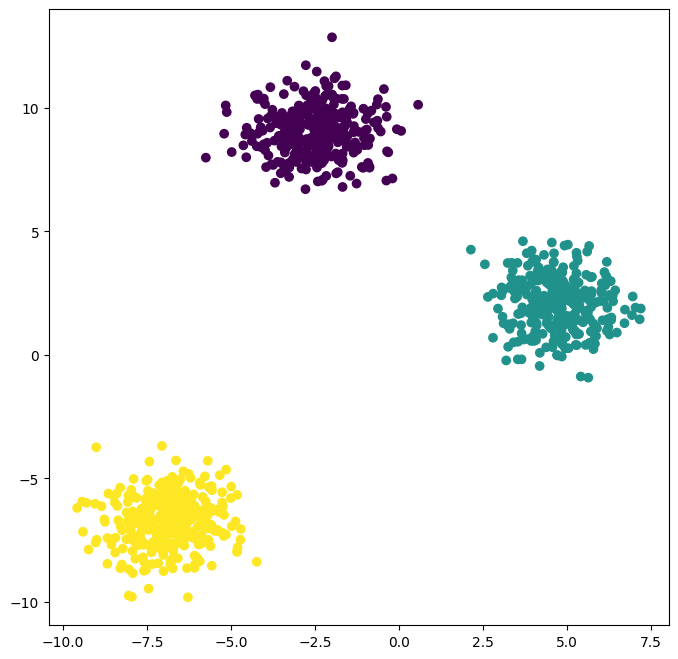

In [10]:
plt.figure(figsize=(8,8))
plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.25)

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
from sklearn.cluster import KMeans

In [14]:
wcss = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i,init="k-means++")
  kmeans.fit(X_train_scaled)
  wcss.append(kmeans.inertia_)

In [15]:
wcss

[1500.0000000000002,
 475.008282303635,
 48.32826902006254,
 42.00879547151671,
 36.076365859227955,
 32.58643503291357,
 26.260512104426386,
 29.884722133813376,
 21.410084496642018,
 20.272911381739135]

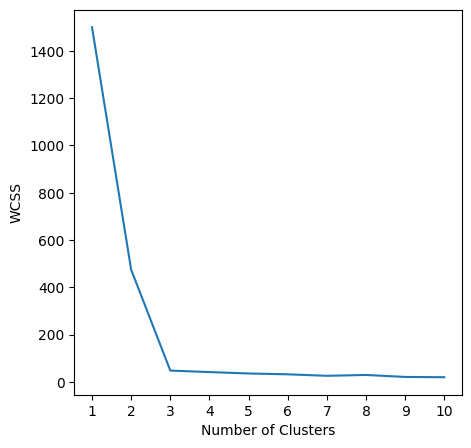

In [21]:
## Plot the elbow
plt.figure(figsize=(5,5))
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [22]:
!pip install kneed

In [25]:
## Validating the Clusters
## Kneelocator

from kneed import KneeLocator

kl = KneeLocator(range(1,11), wcss, curve= 'convex', direction = 'decreasing')

kl.elbow

np.int64(3)

In [27]:
## Silhoutte Score

from sklearn.metrics import silhouette_score

silhoutte_coefficients = []
for k in range(2,11):
  kmeans = KMeans(n_clusters=k, init = "k-means++")
  kmeans.fit(X_train_scaled)
  score = silhouette_score(X_train_scaled,kmeans.labels_)
  silhoutte_coefficients.append(score)

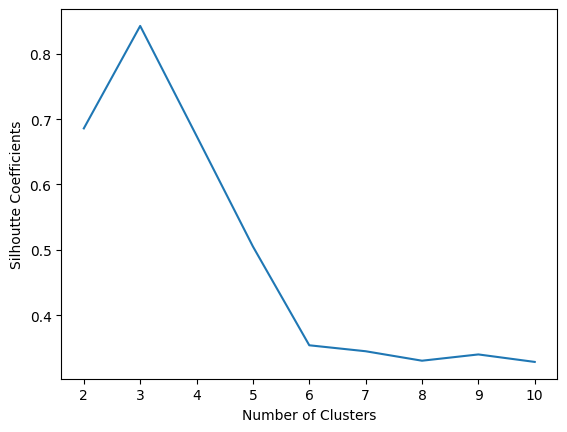

In [28]:
plt.plot(range(2,11),silhoutte_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhoutte Coefficients")
plt.show()